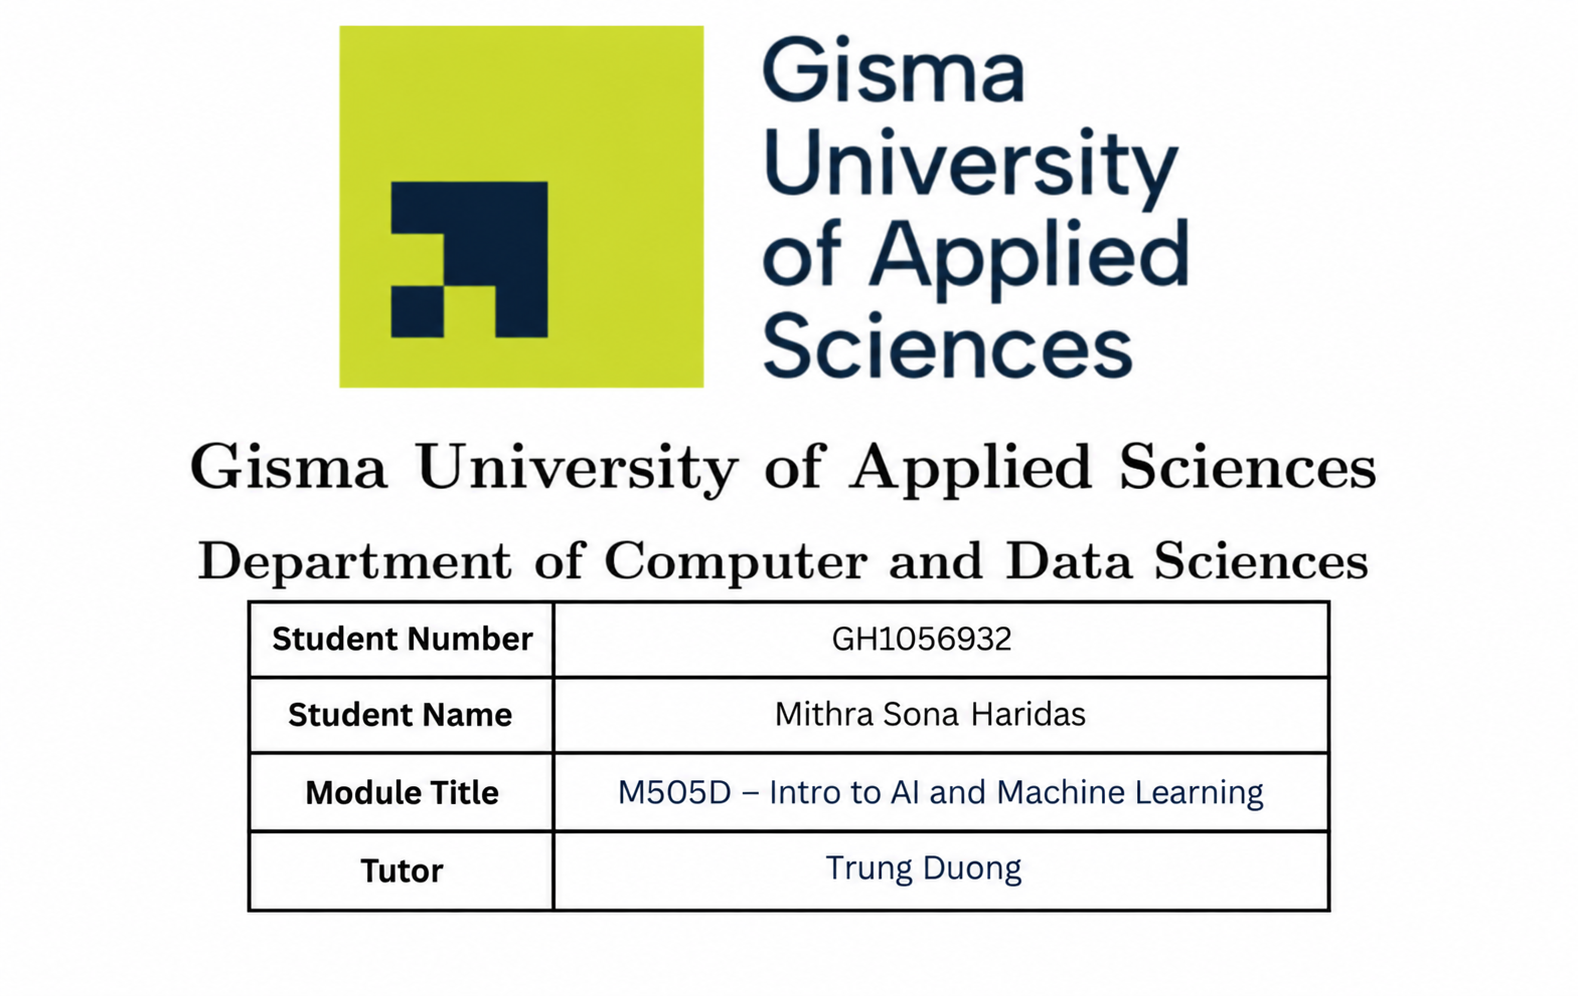

## **PREDICTING ATHLETE RECOVERY OUTCOMES USING MACHINE LEARNING**

---



## **Business Conntext**

This notebook with the Athlete Recovery and Biometric Performance dataset. The intent is to move away from the typical method of checking readiness for a race with cantered training drills to a more data-driven idea of readiness to recover based on a bio marker attitude routine.

Effective recovery management can otherwise mean overtraining, injuries and loss of performance. Coaches and sports scientists based on their experience and a few simple performance parameters can decide whether they can take the athlete to full intensity training, or whether they need to give him/her more recovery.

A number of factors may be aggregated together and patterns identified by adopting machine learning approaches to make more objective predictions. It may also be a way to raise the awareness of the athlete to potential poor recovery markers in a subtle way before they are more obvious.

**Dataset link:** https://www.kaggle.com/datasets/sarveshchhetri/athlete-recovery-and-biometric-performance-dataset

## **Problm Statement**

This project is a study to predict an athlete's daily Recovery Score based on athlete training load, sleep data and other biometric data.

Recovery Score is not a classification problem, as it is not categorized, but it has a range of 0-100.

Poor recovery management can be a cause of overtraining, injury and/or sub-optimal performance. A host of factors can be happening at once, influencing the recovery process and it would be hard to assess realistically without additional analysis. All these can be integrated into a data-driven approach which can more objectively predict an athlete's recovery level.

## **Dataset Description**

This project is based on the Athlete Recovery and Biometric Performance data set, which consists the training length, training intensity, sleep length, resting heart rate, HRV, mood, muscle soreness and energy level. This model could prove useful in the realm of coaching, sports science and athletics itself, as it provides an objective signal based on data to know what state of recovery the athlete is in, which can be used in addition to subjective decision making of coaches when determining training intensity.

## **1. Data Collection**

**Dataset details:**
- **Number of samples:** 8,379 rows
- **Number of features:** 19 (18 input features + 1 target variable)
- **Target variable:** Recovery_Score (continuous, 0–100)


In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Importing from kaggle
df = pd.read_csv('athlete_recovery_synthetic.csv')

df.head()

,Athlete_ID,Day,Day_of_Week,Week,Age,Gender,Sport_Type,Training_Type,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Stress_Level,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
0,1000,1,1,1,28,Male,Team Sport,HIIT,46,7.9,7.7,270,High,59,75,4.3,4.8,5.9,51.1
1,1000,2,2,1,28,Male,Team Sport,Cardio,71,7.0,7.3,258,Low,55,79,5.9,4.0,5.8,63.7
2,1000,3,3,1,28,Male,Team Sport,HIIT,45,7.3,7.7,214,Medium,57,77,5.1,4.0,5.6,71.0
3,1000,4,4,1,28,Male,Team Sport,Cardio,86,7.5,7.9,228,High,61,71,3.0,6.2,2.7,37.2
4,1000,5,5,1,28,Male,Team Sport,HIIT,28,9.2,6.7,0,High,64,62,3.3,7.4,1.1,12.3


## **2. Data Analysis**

In [2]:
#To confirm if i have got the full 8,379-row dataset with all 19 columns
print(df.shape)
print(df.columns.tolist())


(8379, 19)
['Athlete_ID', 'Day', 'Day_of_Week', 'Week', 'Age', 'Gender', 'Sport_Type', 'Training_Type', 'Training_Duration_Min', 'Training_Intensity', 'Sleep_Duration_Hours', 'Caffeine_Intake_mg', 'Stress_Level', 'Resting_Heart_Rate', 'HRV_ms', 'Mood_Score', 'Muscle_Soreness', 'Energy_Level', 'Recovery_Score']


In [3]:
#Displays each column name, its number of non-missing values, and its data type.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8379 entries, 0 to 8378
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Athlete_ID             8379 non-null   int64  
 1   Day                    8379 non-null   int64  
 2   Day_of_Week            8379 non-null   int64  
 3   Week                   8379 non-null   int64  
 4   Age                    8379 non-null   int64  
 5   Gender                 8379 non-null   object 
 6   Sport_Type             8379 non-null   object 
 7   Training_Type          8379 non-null   object 
 8   Training_Duration_Min  8379 non-null   int64  
 9   Training_Intensity     8378 non-null   float64
 10  Sleep_Duration_Hours   7775 non-null   float64
 11  Caffeine_Intake_mg     8379 non-null   int64  
 12  Stress_Level           8379 non-null   object 
 13  Resting_Heart_Rate     8379 non-null   int64  
 14  HRV_ms                 8379 non-null   int64  
 15  Mood

In [4]:
#Summary stats for each column (average, min, max, etc.)
df.describe()

,Athlete_ID,Day,Day_of_Week,Week,Age,Training_Duration_Min,Training_Intensity,Sleep_Duration_Hours,Caffeine_Intake_mg,Resting_Heart_Rate,HRV_ms,Mood_Score,Muscle_Soreness,Energy_Level,Recovery_Score
count,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8378.000000,7775.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000,8379.000000
mean,1149.458647,14.497076,3.998329,2.499821,25.860962,52.789712,6.211506,7.498842,185.348132,57.202888,74.126507,5.177109,5.161953,3.273087,49.061356
std,86.631832,8.078044,2.000417,1.117941,4.531092,21.357704,2.368960,0.693790,112.850208,5.790991,13.981632,1.210072,2.127583,1.679100,27.926347
min,1000.000000,1.000000,1.000000,1.000000,18.000000,10.000000,1.000000,5.000000,0.000000,38.000000,22.000000,1.000000,1.000000,1.000000,0.000000
25%,1074.000000,8.000000,2.000000,2.000000,23.000000,36.000000,4.900000,7.000000,126.000000,53.000000,64.000000,4.400000,3.600000,2.000000,27.800000
50%,1149.000000,14.000000,4.000000,2.000000,26.000000,56.000000,6.600000,7.500000,212.000000,58.000000,74.000000,5.200000,5.200000,3.100000,48.900000
75%,1224.000000,21.000000,6.000000,3.000000,28.000000,69.000000,7.900000,8.000000,268.000000,61.000000,84.000000,6.000000,6.700000,4.300000,69.900000
max,1299.000000,28.000000,7.000000,4.000000,41.000000,115.000000,10.000000,9.500000,400.000000,81.000000,115.000000,9.500000,10.000000,10.000000,100.000000


In [5]:
# Count how many rows are exact duplicates
print('Number of duplicate rows:', df.duplicated().sum())

Number of duplicate rows: 0


In [6]:
# Counts missing (NaN) values in each column
# Any column with a number > 0 has missing data that needs handling later
df.isnull().sum()

,0
Athlete_ID,0
Day,0
Day_of_Week,0
Week,0
Age,0
Gender,0
Sport_Type,0
Training_Type,0
Training_Duration_Min,0
Training_Intensity,1


## **3. Exploratory Data Analysis**

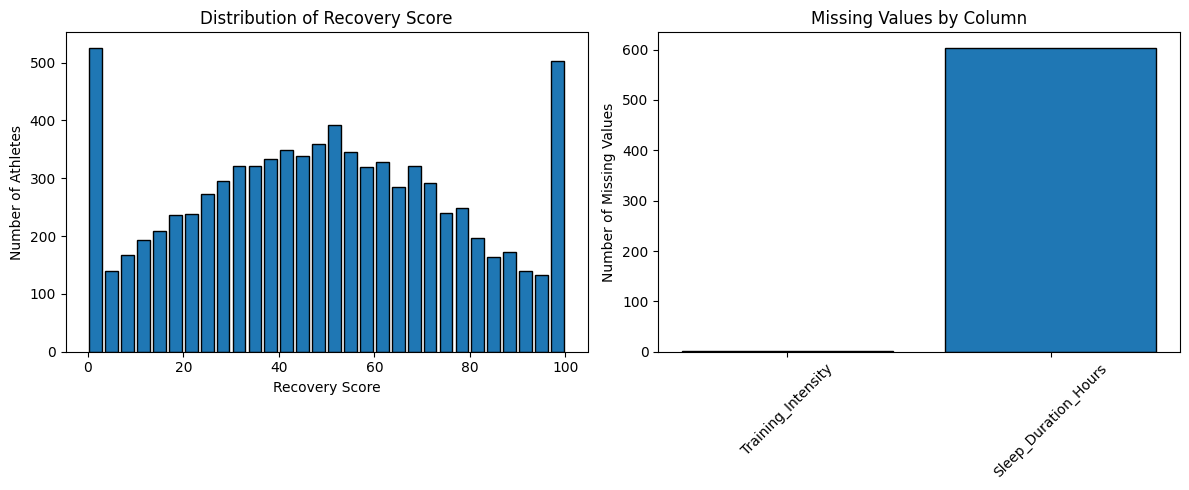

In [7]:
#Combined EDA overview: Recovery Score distribution and missing values in one figure
import matplotlib.pyplot as plt

fig, ax_grid = plt.subplots(1, 2, figsize=(12, 5))

# Left: Recovery_Score distribution
ax_grid[0].hist(df['Recovery_Score'], bins=30, edgecolor='black', rwidth=0.8)
ax_grid[0].set_title('Distribution of Recovery Score')
ax_grid[0].set_xlabel('Recovery Score')
ax_grid[0].set_ylabel('Number of Athletes')

# Right: missing values by column
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
ax_grid[1].bar(missing_counts.index, missing_counts.values, edgecolor='black')
ax_grid[1].set_title('Missing Values by Column')
ax_grid[1].set_ylabel('Number of Missing Values')
ax_grid[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Two feature visualizations

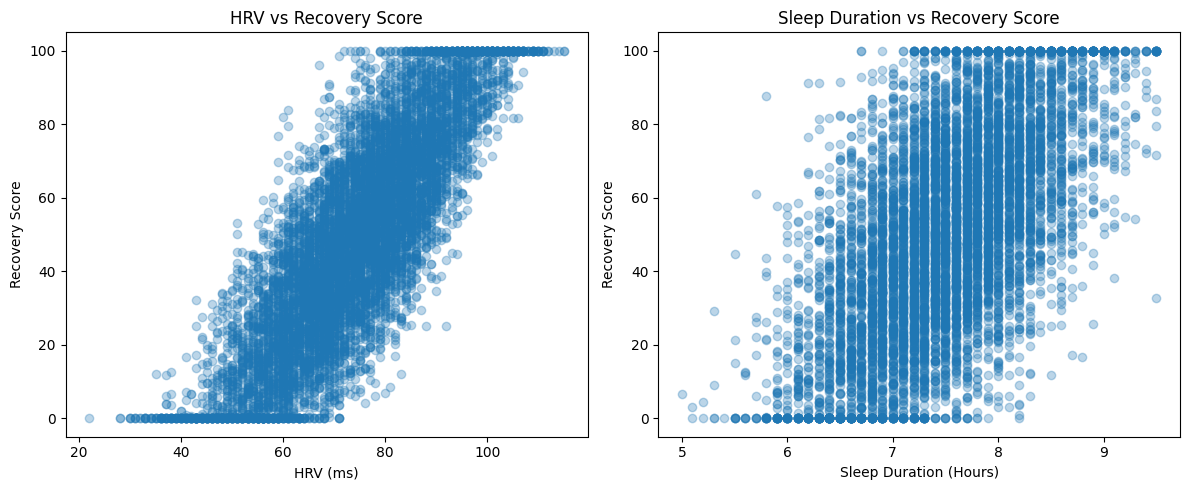

In [8]:
#numeric features and how they relate to Recovery_Score.
#Scatter plots showing how HRV and Sleep relate to Recovery_Score
#It helps spot whether these features have a visible relationship with the target

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['HRV_ms'], df['Recovery_Score'], alpha=0.3)
axes[0].set_xlabel('HRV (ms)')
axes[0].set_ylabel('Recovery Score')
axes[0].set_title('HRV vs Recovery Score')

axes[1].scatter(df['Sleep_Duration_Hours'], df['Recovery_Score'], alpha=0.3)
axes[1].set_xlabel('Sleep Duration (Hours)')
axes[1].set_ylabel('Recovery Score')
axes[1].set_title('Sleep Duration vs Recovery Score')

plt.tight_layout()
plt.show()

Increased HRV is related to an increased Recovery Score, and increased Sleep Duration is related to an increased Recovery Score. HRV is trending with a good sense of direction that may mean it is one of the more important metrics; Sleep Duration is trending upwards and becoming more scattered, which indicates that recovery isn't just sleep.


### Correlation heatmap

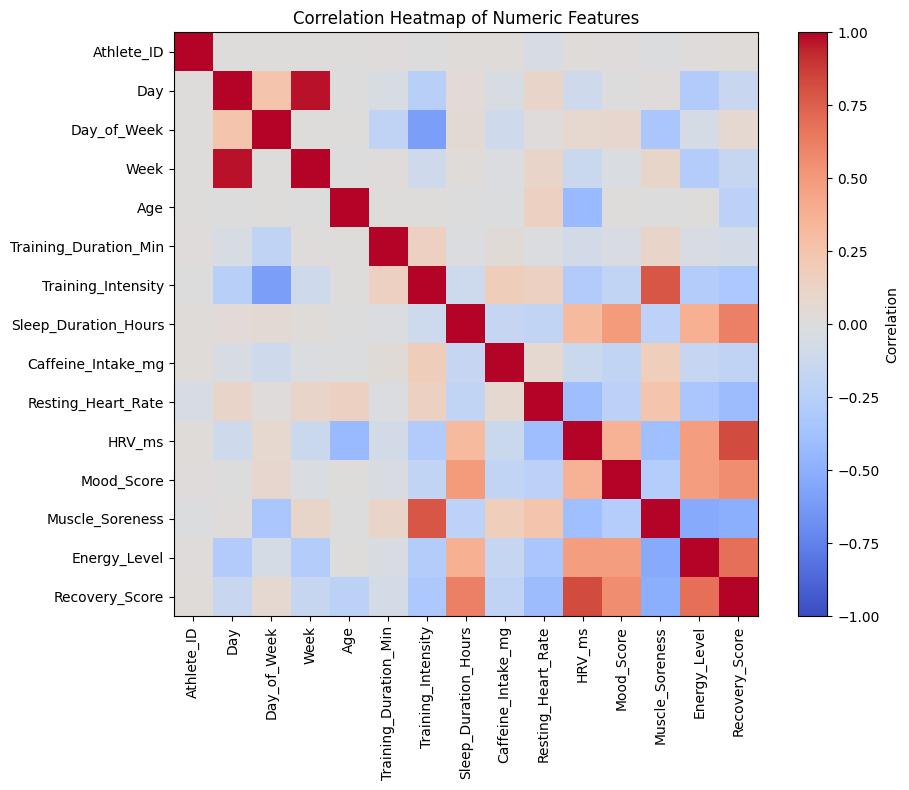

In [9]:
#this shows how ALL numeric features relate to each other and to the target at once not just two at a time.
import numpy as np

#Shows how strongly numeric features are related to each other and to Recovery_Score
#Values near +1 or -1 show a strong relationship, while values around 0 indicate a weak or no relationship.
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

HRV_ms and Energy_Level exhibit the greatest positive correlation with Recovery_Score and Resting_Heart_Rate and Muscle_Soreness demonstrate negative correlations physiologically sound as greater recovery is associated with increased HRV and greater energy with decreased heart rate and muscle soreness. Looking at the other correlations, most of the other features' correlations are relatively low, suggesting that the model will be the combination of many features, without any of them being a strong predictor.


## **4. Data Cleaning and Preprocessing**


In [10]:
from sklearn.impute import SimpleImputer

# Median is less affected by outliers than mean
num_imputer = SimpleImputer(strategy='median')
df[['Sleep_Duration_Hours', 'Training_Intensity']] = num_imputer.fit_transform(
    df[['Sleep_Duration_Hours', 'Training_Intensity']]
)

print(df[['Sleep_Duration_Hours', 'Training_Intensity']].isnull().sum())

Sleep_Duration_Hours    0
Training_Intensity      0
dtype: int64


## **5.Data Preparation and Feature Engineering**

In [11]:
#ENCODING THE CATEGORIAL COLUMNS

from sklearn.preprocessing import OneHotEncoder

#Converting categorical values into numbers so the models can process them.
#OneHotEncoder creates a separate 0/1 column for each category
categorical_cols = ['Gender', 'Sport_Type', 'Training_Type', 'Stress_Level']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_array = encoder.fit_transform(df[categorical_cols])

# Turn the result into a proper DataFrame with readable column names
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols))
encoded_df.head()

,Gender_Female,Gender_Male,Gender_Non-binary,Sport_Type_Combat,Sport_Type_Endurance,Sport_Type_Mixed,Sport_Type_Strength,Sport_Type_Team Sport,Training_Type_Cardio,Training_Type_HIIT,Training_Type_Rest,Training_Type_Strength,Training_Type_Yoga,Stress_Level_High,Stress_Level_Low,Stress_Level_Medium
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


## **6. Splitting into training set and test sets**

In [12]:
from sklearn.model_selection import train_test_split

#Separate features (X) from what we're predicting (y)
X = df.drop('Recovery_Score', axis=1)
y = df['Recovery_Score']

#Also drop identifier columns that aren't real predictive features
X = X.drop(['Athlete_ID', 'Day', 'Day_of_Week', 'Week'], axis=1)

#Spliting into 80% training data, 20% test data
#random_state=42 makes the split reproducible (same split every time you run it)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)

Training set size: (6703, 14)
Test set size: (1676, 14)


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ['Age', 'Training_Duration_Min', 'Training_Intensity',
                     'Sleep_Duration_Hours', 'Caffeine_Intake_mg',
                     'Resting_Heart_Rate', 'HRV_ms', 'Mood_Score',
                     'Muscle_Soreness', 'Energy_Level']

categorical_features = ['Gender', 'Sport_Type', 'Training_Type', 'Stress_Level']

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

-Categorical features (Gender, Sport_Type, Training_Type, Stress_Level)
were one-hot encoded, and numeric features were standardized using
StandardScaler.

-Both are put together in one ColumnTransformer which ensures that the preprocessing will only be learnt from the training set and not from the test set otherwise data leakage will occur.



**Why Pipeline matters**

There are a couple reasons why preprocessing together with the model is important: First, data leakage is avoided, because transformations are learned only from the training examples and not from all offered data before splitting; second, this will keep comparisons of the models fair, as an example, Linear Regression will have exactly the same preprocessing as Random Forest; third, it keeps the hyperparameters simple to tune as example, GridSearchCV will refit the preprocessing correctly for each fold of the cross-validation.


## **Training two different models**

### First Model - Linear Regression

In [14]:
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
print('Linear Regression trained successfully')

Linear Regression trained successfully


First Linear Regression was trained as a simple interpretable baseline model with the preprocessing pipeline outlined above, such that missing values, encoding, and scaling were all processed in an identical manner.

### Second Model - Random Forest

In [15]:
#Training second model
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Same pipeline structure as Linear Regression, but with a different model
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
print('Random Forest trained successfully')

Random Forest trained successfully


Random Forest Regressor has been trained with the same data pre-processing steps and split of data as in the above first model, therefore it can be compared with the above first model. Unlike Linear Regression, it can be used to just recognize the non linear relationship in the data, on the basis of several decision trees.

### Preprocessing Comparison- Scaling


In [16]:
# Compare Random Forest performance WITH vs WITHOUT scaling the numeric features
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score

# Same as the original preprocessor, but skip StandardScaler this time
numeric_pipeline_noscale = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
    # no scaler — that's the only change from before
])

# Categorical part stays exactly the same
categorical_pipeline_noscale = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

#connecting both into one preprocessor, just like before but without scaling
preprocessor_noscale = ColumnTransformer(transformers=[
    ('num', numeric_pipeline_noscale, numeric_features),
    ('cat', categorical_pipeline_noscale, categorical_features)
])

# Train a Random Forest using the unscaled version
rf_pipeline_noscale = Pipeline(steps=[
    ('preprocessor', preprocessor_noscale),
    ('model', RandomForestRegressor(random_state=42))
])
rf_pipeline_noscale.fit(X_train, y_train)

# Get predictions and R² score for the unscaled version
y_pred_rf_noscale = rf_pipeline_noscale.predict(X_test)
r2_rf_noscale = r2_score(y_test, y_pred_rf_noscale)

# Get R² score for the original scaled version (already trained earlier)
y_pred_rf_scaled = rf_pipeline.predict(X_test)
r2_rf_scaled = r2_score(y_test, y_pred_rf_scaled)

# Print both scores side by side
print('Random Forest R² WITHOUT scaling:', round(r2_rf_noscale, 4))
print('Random Forest R² WITH scaling:   ', round(r2_rf_scaled, 4))
print('Difference:', round(abs(r2_rf_noscale - r2_rf_scaled), 4))

Random Forest R² WITHOUT scaling: 0.8929
Random Forest R² WITH scaling:    0.8932
Difference: 0.0003


We use scaling for Random Forest because as Random Forest is scale independent, as the value of R2 is almost the same with (0.8932) and without (0.8929) scaling the data, with a difference of 0.0003. Which is why a shared Pipeline using a ColumnTransformer is a good idea; each model gets the pre-processing they need.

### Data Engineering Comparison

In [17]:
# Compare two preprocessing strategies on Random Forest:
# Strategy A = current preprocessing (impute + encode + scale)
# Strategy B = Strategy A + feature selection (keep only the best features)
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Strategy A: this is just the existing rf_pipeline, already trained
y_pred_strategy_a = rf_pipeline.predict(X_test)
r2_strategy_a = r2_score(y_test, y_pred_strategy_a)

# Strategy B: same preprocessing, but add SelectKBest to keep only the top 10 features
rf_pipeline_selectk = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression, k=10)),
    ('model', RandomForestRegressor(random_state=42))
])
rf_pipeline_selectk.fit(X_train, y_train)
y_pred_strategy_b = rf_pipeline_selectk.predict(X_test)
r2_strategy_b = r2_score(y_test, y_pred_strategy_b)

# Print both scores side by side
print('Strategy A (no feature selection) R2:', round(r2_strategy_a, 4))
print('Strategy B (with feature selection, k=10) R2:', round(r2_strategy_b, 4))
print('Difference:', round(r2_strategy_a - r2_strategy_b, 4))

Strategy A (no feature selection) R2: 0.8932
Strategy B (with feature selection, k=10) R2: 0.8932
Difference: -0.0


### Comparing preprocessing strategies

For Strategy A the entire preprocessing pipeline was carried out and for Strategy B feature selection was included and the top 10 features with the highest correlation to Recovery Score were saved. In both cases the features that were removed were almost alike (R² of 0.8932 vs 0.8932), and this is the behaviour of the RF that 99.99% features can be categorical. In this case, feature selection did not result in better R², but could be helpful to improve training time or to avoid overfitting in more “noisy” cases.


## **7. Comparing Model Performance**

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Get predictions from both trained models
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# Compare both models using the same three metrics
for name, y_pred in [('Linear Regression', y_pred_lr), ('Random Forest', y_pred_rf)]:
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f'{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}')

Linear Regression: MAE=7.24, RMSE=9.17, R2=0.892
Random Forest: MAE=7.13, RMSE=9.14, R2=0.893


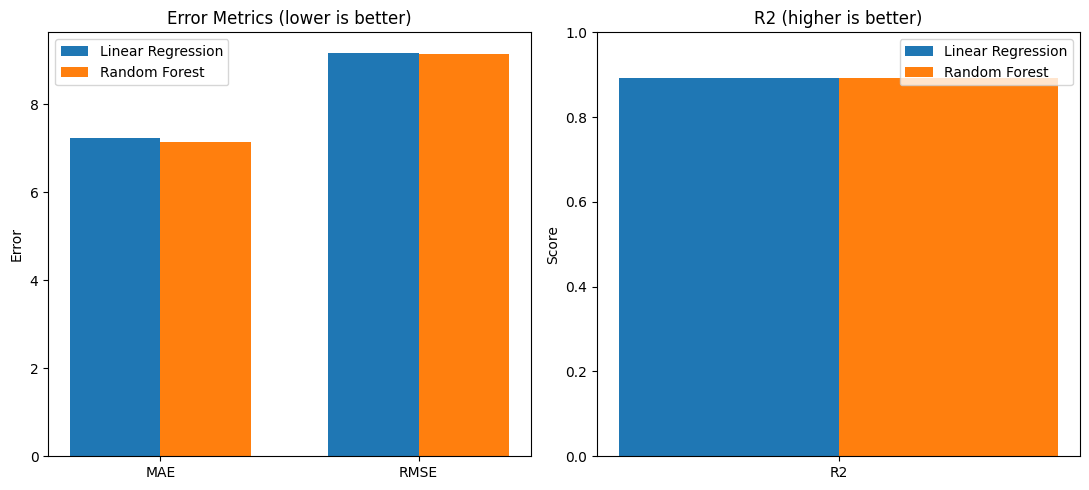

In [19]:
# Chart comparing Linear Regression vs Random Forest
# MAE and RMSE go in one chart, R2 gets its own chart since its scale is very different
import matplotlib.pyplot as plt
import numpy as np

# Error scores for both models (lower = better)
lr_error_scores = [
    mean_absolute_error(y_test, y_pred_lr),
    np.sqrt(mean_squared_error(y_test, y_pred_lr))
]
rf_error_scores = [
    mean_absolute_error(y_test, y_pred_rf),
    np.sqrt(mean_squared_error(y_test, y_pred_rf))
]

# R2 scores for both models (higher = better)
lr_r2 = r2_score(y_test, y_pred_lr)
rf_r2 = r2_score(y_test, y_pred_rf)

# Create two charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# Left chart: MAE and RMSE bars
x1 = np.arange(2)
width = 0.35
ax1.bar(x1 - width/2, lr_error_scores, width, label='Linear Regression')
ax1.bar(x1 + width/2, rf_error_scores, width, label='Random Forest')
ax1.set_xticks(x1)
ax1.set_xticklabels(['MAE', 'RMSE'])
ax1.set_ylabel('Error')
ax1.set_title('Error Metrics (lower is better)')
ax1.legend()

# Right chart: R2 bars, own scale so the difference is visible
x2 = np.arange(1)
ax2.bar(x2 - width/2, [lr_r2], width, label='Linear Regression')
ax2.bar(x2 + width/2, [rf_r2], width, label='Random Forest')
ax2.set_xticks(x2)
ax2.set_xticklabels(['R2'])
ax2.set_ylim(0, 1)
ax2.set_ylabel('Score')
ax2.set_title('R2 (higher is better)')
ax2.legend()

plt.tight_layout()
plt.show()

Random Forest provides a slight improvement on all three measures in comparison with Linear Regression and the difference is very small (R² = 0.893 vs 0.892).This means that for example, HRV and Recovery_Score are mostly linearly related, and the non-linear nature of the system captured by the Random Forest algorithm, is of negligible importance here.The advantage of the simplicity and interpretability of Linear Regression is that it provides a great option for the same accuracy as Random Forest has slightly more.

##**8. Improving Model Performance**

In [20]:
from sklearn.model_selection import GridSearchCV

# Smaller, faster search - still gives real tuning results
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20],
    "model__min_samples_leaf": [1, 4]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best cross-validation R2:', grid_search.best_score_)


Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}
Best cross-validation R2: 0.8891918232989008


Evaluated 8 combinations of hyperparameters with 3-fold cross-validation using GridSearchCV. Fitting the best configuration (200 trees, max depth 10, min samples per leaf 4) resulted in R² = 0.889 which is very close to what had been obtained with the default setting (R² = 0.893), indicating that the default settings were likely near optimal.

### Hyperparameter Effect Visualization

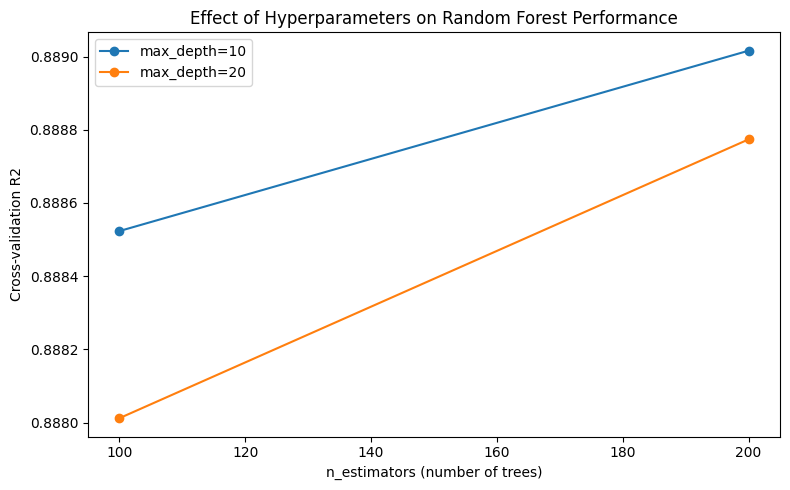

In [21]:
# Show how Random Forest's score changed across different hyperparameter values
import pandas as pd
import matplotlib.pyplot as plt

# Turn GridSearchCV's results into a table we can work with
results_df = pd.DataFrame(grid_search.cv_results_)

# Pull out just the columns we need: the hyperparameter values and their scores
results_df = results_df[[
    'param_model__n_estimators',
    'param_model__max_depth',
    'mean_test_score'
]]

# Average the score across min_samples_leaf, so we can plot n_estimators vs max_depth cleanly
grouped = results_df.groupby(
    ['param_model__n_estimators', 'param_model__max_depth']
)['mean_test_score'].mean().reset_index()

# Plot one line per max_depth value
plt.figure(figsize=(8, 5))
for depth in grouped['param_model__max_depth'].unique():
    subset = grouped[grouped['param_model__max_depth'] == depth]
    plt.plot(
        subset['param_model__n_estimators'],
        subset['mean_test_score'],
        marker='o',
        label=f'max_depth={depth}'
    )

# Labels and formatting
plt.xlabel('n_estimators (number of trees)')
plt.ylabel('Cross-validation R2')
plt.title('Effect of Hyperparameters on Random Forest Performance')
plt.legend()
plt.tight_layout()
plt.show()

Notice that the range of the y-axis (Cross-validation R²) is very small (from 0.888 to 0.889) and thus the trends are clearly visible, but there is not a huge difference between the actual performance measured in R² across all of the hyperparameter sets — similar to the above results where the untuned Random Forest was near optimum.

###Learning curve

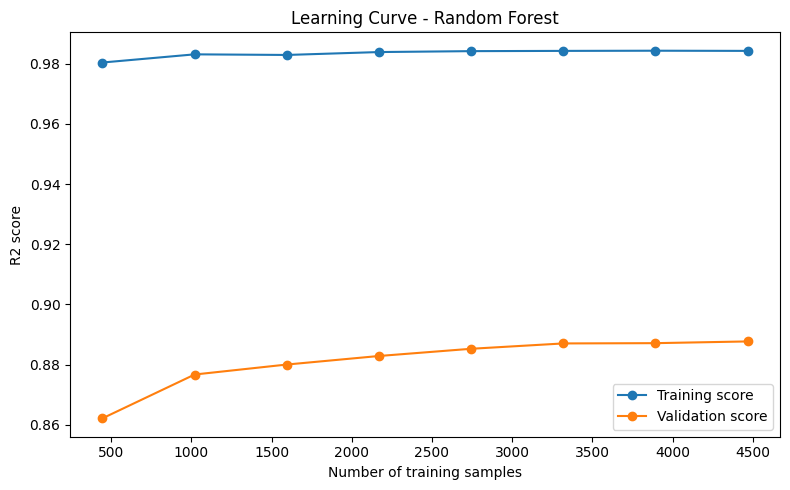

In [22]:
# Learning curve: shows how training and validation score change
# as the model is given more training data
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Try the model on increasing chunks of the training data (10% to 100%)
train_sizes, train_scores, val_scores = learning_curve(
    estimator=rf_pipeline,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3,
    scoring='r2'
)

# Average the scores across the 3 cross-validation folds
train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)

#Ploting both lines
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores_mean, marker='o', label='Training score')
plt.plot(train_sizes, val_scores_mean, marker='o', label='Validation score')
plt.xlabel('Number of training samples')
plt.ylabel('R2 score')
plt.title('Learning Curve - Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

With larger amounts of data the score for "Training" is still quite high (~0.98) while the score for "Validation" goes up from 0.86 to ~0.89, showing mild overfitting common for RF and suggesting minute improvements can be achieved with additional training data.

### Tuning a second model — Ridge Regression

In [23]:
# Ridge Regression = Linear Regression + a penalty that shrinks large coefficients
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Same pipeline setup as before, but using Ridge instead of plain LinearRegression
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

# alpha controls how much the coefficients get shrunk - this is the thing we're tuning
ridge_param_grid = {
    "model__alpha": [0.1, 1, 10, 50, 100]
}

# Try all 5 alpha values using 3-fold cross-validation, keep the best one
ridge_grid_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=3,
    scoring='r2'
)

# Train and search for the best alpha
ridge_grid_search.fit(X_train, y_train)

# Show the best alpha found and its cross-validation score
print('Best alpha:', ridge_grid_search.best_params_)
print('Best cross-validation R²:', round(ridge_grid_search.best_score_, 4))

Best alpha: {'model__alpha': 10}
Best cross-validation R²: 0.8883


Ridge Regression was used instead of Linear Regression, and the alpha was tuned using 3-fold cross-validated values across 5 points, and using the same preprocessor for a fair comparison

## **9. Final Evaluation on Test Data**


In [24]:
#Comparing both models to check which worked better.
# Use the best Random Forest found by GridSearchCV
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

# Final comparison: Linear Regression vs tuned Random Forest, on the test set
final_results = {
    'Linear Regression': y_pred_lr,
    'Tuned Random Forest': y_pred_best_rf
}

for name, y_pred in final_results.items():
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f'{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}')

Linear Regression: MAE=7.24, RMSE=9.17, R2=0.892
Tuned Random Forest: MAE=7.07, RMSE=9.07, R2=0.895


Random Forest barely outperforms Linear Regression on all the metrics: MAE 7.07 compared to Linear Regression's 7.24, RMSE 9.07 compared to Linear Regression's 9.17 and R² of 0.895 compared to 0.892 for linear regression.


### Feature importance plot

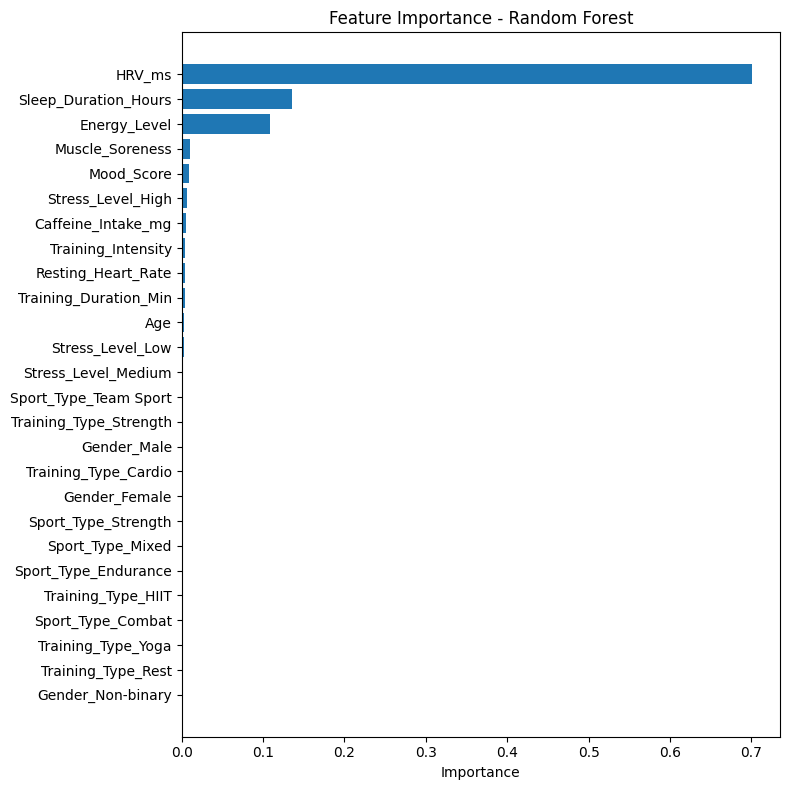

In [25]:
# Show which features mattered most to the Random Forest model
import pandas as pd
import matplotlib.pyplot as plt

# Get the feature names after preprocessing (numeric + one-hot encoded categorical)
feature_names = (
    numeric_features +
    list(best_rf.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['encoder']
         .get_feature_names_out(categorical_features))
)

# Get importance scores from the trained Random Forest model
importances = best_rf.named_steps['model'].feature_importances_

# Put feature names and their importance into a table, sorted highest first
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot as a horizontal bar chart, most important feature on top
plt.figure(figsize=(8, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()  # highest importance at the top
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

This aligns with the results seen in the correlation heatmap above, where HRV_ms is the highest followed by Sleep_Duration_Hours. Despite there being many categorical variables, they are relatively unimportant compared to the number of them, and the model is almost entirely based on the numeric biometric and sleep data when making the prediction.


## **10.Conclusion**



**Summary of findings**
This project built and tested a machine learning pipeline that can predict the Recovery Score from the Athlete Recovery and Biometric Performance dataset (8379 records, 19 features), comparing the results of 2 models: Linear Regression (a simple model that can be easily understood) and Random Forest Regressor - a model chosen because it was able to capture non-linear relationships.


**Practical Implications**
In simple words easily-measurable measurements like HRV, RHR, in combination with a model like this, could help coaches and sports scientists to make earlier training load adjustments that would prevent overtraining or injury in athletes at risk of poor recovery.


**Critical Evaluation :**
The is the two models simple linear baseline and non-linear ensemble method and the purpose of this project was made clear because it was not a single model, but two meaningful models where the data leakage was avoided using a scikit-learn Pipeline and ColumnTransformer. Hyperparameters were not set to default values, but rather using cross-validated GridSearchCV. The two best predictors are Energy_Level and HRV_ms and the reason being that they are physiologically plausible it's easy to be sure they're capturing the signal and not the noise.


**Limitations:**
All data is synthetically generated, and noise and variation in actual athlete physiology may not contain as much noise as this data set. Another assumption of the models is each day's results are independent; that is, the trend from the prior days for the same athlete is not considered. Other features like Sport_Type and Training_Type were not correlated with the target as much, which created a need for further granularization of these features.


**Future Improvements:**
Other models could be tested, such as using engineered time based features such as day rolling averages. Further, the model should be validated using real athlete data in order to improve this analysis greatly.


**Ethical issues:**
This model cannot be used to replace the coaching and sport scientists' professional judgement as the length of training or playing time or even selection criteria could be affected by the prediction of a recovery. Unless there is an avenue to uncover the error in the prediction indicating an athlete is "fully recovered" without man intervention, they could overwork themselves or sustain an injury. Athlete's real data were sensitive and would require informed consent and careful handling of such data with a clear communication on what is being collected and how predictions are being used.

# 10.Tools Used

- Python
- pandas
- NumPy
- scikit-learn
- matplotlib
- Google Colab


# 11.References
**References**

- Dataset: Athlete Recovery and Biometric Performance Dataset (Kaggle, uploaded by sarveshchhetri). Available at: https://www.kaggle.com/datasets/sarveshchhetri/athlete-recovery-and-biometric-performance-dataset

- scikit-learn documentation, consulted for: SimpleImputer, OneHotEncoder, StandardScaler, ColumnTransformer, Pipeline, train_test_split, LinearRegression, RandomForestRegressor, GridSearchCV, and the regression metrics module. Available at: https://scikit-learn.org/stable/